In [1]:
#imports

#data handling
import os
import re 
import gc 
import pandas as pd
import numpy as np
import chardet
import string
import time

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns
#Text preprocessing 
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import TreebankWordTokenizer
#Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from collections import Counter
# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

#SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import BorderlineSMOTE

# TextBlob for polarity and subjectivity
from textblob import TextBlob

from sklearn.pipeline import FeatureUnion
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier  

# Custom Transformer for TextBlob features
from sklearn.base import BaseEstimator, TransformerMixin
import scipy.sparse as sparse
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler

from imblearn.over_sampling import RandomOverSampler
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # type: ignore


In [2]:
#NLTK downloads
#nltk.download('stopwords')
#nltk.download('wordnet')
#nltk.download('omw-1.4')

In [3]:
# detect encoding 
with open("Dataset-updated.csv", "rb") as f:
    rawdata = f.read(500000)   
result = chardet.detect(rawdata)
encoding = result["encoding"]

print("Detected Encoding:", encoding)


Detected Encoding: MacRoman


In [59]:
#load dataset
df = pd.read_csv(
    "Dataset-updated.csv",
    encoding='MacRoman',     
    engine='python',      
    on_bad_lines='skip'   
)
df = df.sample(frac=1, random_state=52).reset_index(drop=True)
df.head()


,text,label
0,@Jules_Clarke @jmcefalas has more emotional impact when it's the face of a person reading it out loud.,not_cyberbullying
1,"Freshman of high school. My mother just died. Teachers asked ""Well, does your mother call you that?"", and when I ask about a math problem in class (for the first time; I was always bullied, so I s...",cyberbullying
2,"Similalry, I love ""Christian Woman"", how it starts soft, then kinda stops, and then kicks right into it with the full band. There were some good tunes on that disc",cyberbullying
3,@BrownBagPantry @LaurieJWillberg I haven't seen anything that falls under the lines of targeted harassment in any screenshots/archives.,cyberbullying
4,RT @Wi5hy Im not sexist but women shouldnt be allowed to drive.,cyberbullying


In [60]:
#DATASET SHAPE & INFO
print("Shape:", df.shape)
print("\nColumns:", df.columns)
df.info()
df.describe(include='all')
print(df['label'].value_counts())


Shape: (63742, 2)

Columns: Index(['text', 'label'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63742 entries, 0 to 63741
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    63742 non-null  object
 1   label   63742 non-null  object
dtypes: object(2)
memory usage: 996.1+ KB
label
cyberbullying         44789
not_cyberbullying     18953
Name: count, dtype: int64


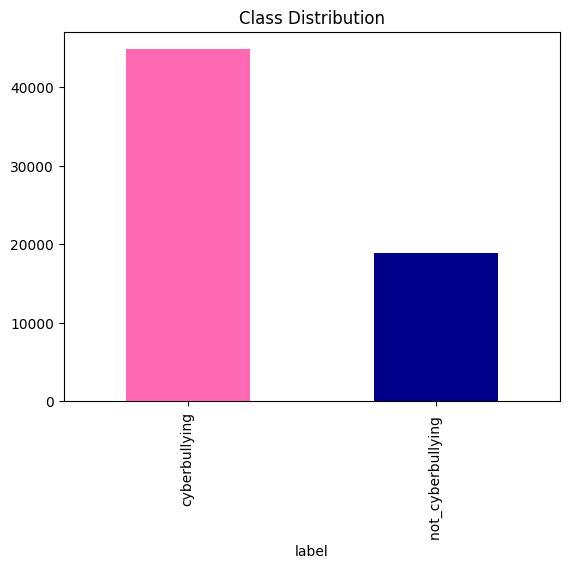

label
cyberbullying         0.702661
not_cyberbullying     0.297339
Name: proportion, dtype: float64

In [61]:
#check class distribution
df['label'].value_counts().plot(kind='bar', color=['hotpink','darkblue'])
plt.title("Class Distribution")
plt.show()

df['label'].value_counts(normalize=True)


In [7]:
stop_words = set(stopwords.words('english'))
print(stop_words)

{'about', 'once', "it's", 'hadn', 'm', 'more', 'did', 'they', 'before', 'further', "should've", 'after', "they've", 'by', 'o', 'whom', 'now', 'very', 'herself', 'this', 'having', 'were', 'through', 'myself', "he's", 't', "haven't", 'ma', 'between', 'mightn', 'to', 'are', 'you', 'he', "he'd", "you're", 'do', 'will', 'as', "doesn't", 'ourselves', 'on', "you've", "needn't", 'been', 'those', 'needn', 'during', 'so', 'ours', 'mustn', 'up', 'such', "it'll", 'doesn', 'doing', 'yourselves', 'won', "shan't", "they'd", "wouldn't", "i'll", 'd', 'your', 'just', 'we', "you'd", 'should', 'then', "she's", "mustn't", 'll', 'yours', "aren't", 'if', 'their', "they'll", 'while', "you'll", 'shan', 'her', 'any', 'until', 'out', 'its', 'down', 'over', 'that', 'be', 'isn', "we're", 'was', "he'll", 'at', "couldn't", 'our', 'a', 'again', 'only', 'ain', 'and', 'because', 'few', 'him', 'most', "won't", 'don', 'under', "hasn't", 'yourself', "weren't", 'into', "wasn't", "she'd", 'these', 'who', 'himself', 'off', '

In [62]:
# Cleaning & normalization with PROPER Tokenization, Stemming & Lemmatization


# Initialize - Added TreebankWordTokenizer for proper tokenization
wnl = WordNetLemmatizer()
ps = PorterStemmer()  # For stemming (optional - see below)
tokenizer = TreebankWordTokenizer()  # PROPER tokenizer instead of split()
base_stop = set(stopwords.words('english'))

# Custom extra stop tokens observed in your top words
custom_stop_extra = {
    'rt', 'amp', 'u', 'im', 'mkr', 'dont', 'like', 'one', 'get', 'know',
    'think', 'people', 'dont', 'us', 'also', 'school','time','get'
}

# Optionally keep some short meaningful tokens
allow_short = {'no','ok','ah'} 

# Contraction normalizations (basic)
contraction_map = {
    r"\bim\b": "i am",
    r"\bur\b": "you are",
    r"\bu\b": "you",
    r"\bdont\b": "do not",
    r"\bdoesnt\b": "does not",
    r"\bdidnt\b": "did not",
    r"\bive\b": "i have",
    r"\bshes\b": "she is",
    r"\bhe's\b": "he is",
    r"\bthats\b": "that is"
}

# regex patterns
URL_RE = re.compile(r"http\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
HTML_ENTITY_RE = re.compile(r"&\w+;|&amp;")
NON_ALPHANUM_RE = re.compile(r"[^a-zA-Z0-9\s]")
REPEAT_CHAR_RE = re.compile(r"(.)\1{2,}")  # reduce repeated chars

def clean_text_improved(text):
    """
    Clean text with proper TOKENIZATION, STEMMING, and LEMMATIZATION.
    
    Process:
    1. Lowercase and remove URLs, mentions, HTML entities
    2. Normalize contractions
    3. Remove punctuation and collapse repeated characters
    4. TOKENIZE using TreebankWordTokenizer (better than split())
    5. Remove stopwords, digits, short tokens
    6. LEMMATIZE (converts words to their base form - more accurate than stemming)
    
    Note: Currently using LEMMATIZATION only (more accurate).
    To use STEMMING instead, uncomment the stemming line and comment out lemmatization.
    """
    if not isinstance(text, str):
        text = str(text)
    txt = text.lower()
    # remove urls, mentions, html entities
    txt = URL_RE.sub(" ", txt)
    txt = MENTION_RE.sub(" ", txt)
    txt = HTML_ENTITY_RE.sub(" ", txt)
    # normalize common contractions/chat tokens
    for patt, repl in contraction_map.items():
        txt = re.sub(patt, repl, txt)
    # remove punctuation but keep spaces and alphanumerics
    txt = NON_ALPHANUM_RE.sub(" ", txt)
    # collapse repeated characters (loooove -> loove)
    txt = REPEAT_CHAR_RE.sub(r"\1\1", txt)
    
    # PROPER TOKENIZATION using TreebankWordTokenizer (NOT simple split!)
    toks = tokenizer.tokenize(txt)
    
    clean_toks = []
    for t in toks:
        # remove digits
        if t.isdigit():
            continue
        # remove tokens (<=2) unless in allow_short
        if len(t) <= 2 and t not in allow_short:
            continue
        # remove tokens in custom stoplist
        if t in custom_stop_extra:
            continue
        # remove stopwords
        if t in base_stop:
            continue
        
        # STEMMING (faster, cruder) - Currently commented out
        stemmed = ps.stem(t)
        clean_toks.append(stemmed)
        
        # LEMMATIZATION (slower, more accurate) - Currently ACTIVE
        # Apply verb lemmatization first, then noun
        lemma = wnl.lemmatize(t, pos='v')  # verb form first
        lemma = wnl.lemmatize(lemma, pos='n')  # then noun form
        
        # final length check
        if len(lemma) <= 1:
            continue
        clean_toks.append(lemma)
    
    return " ".join(clean_toks)

# Apply to dataframe
print('Starting text cleaning with proper tokenization and lemmatization...')
df['clean_text'] = df['text'].astype(str).map(clean_text_improved)
print(f'Cleaned {len(df)} texts successfully!')

# Quick check: top 10 cleaned examples
df[['text','clean_text']].head(10)


Starting text cleaning with proper tokenization and lemmatization...
Cleaned 63742 texts successfully!


,text,clean_text
0,@Jules_Clarke @jmcefalas has more emotional impact when it's the face of a person reading it out loud.,emot emotional impact impact face face person person read read loud loud
1,"Freshman of high school. My mother just died. Teachers asked ""Well, does your mother call you that?"", and when I ask about a math problem in class (for the first time; I was always bullied, so I s...",freshman freshman high high mother mother die die teacher teacher ask ask well well mother mother call call ask ask math math problem problem class class first first alway always bulli bully stop ...
2,"Similalry, I love ""Christian Woman"", how it starts soft, then kinda stops, and then kicks right into it with the full band. There were some good tunes on that disc",similalri similalry love love christian christian woman woman start start soft soft kinda kinda stop stop kick kick right right full full band band good good tune tune disc disc
3,@BrownBagPantry @LaurieJWillberg I haven't seen anything that falls under the lines of targeted harassment in any screenshots/archives.,seen see anyth anything fall fall line line target target harass harassment screenshot screenshots archiv archive
4,RT @Wi5hy Im not sexist but women shouldnt be allowed to drive.,sexist sexist women woman shouldnt shouldnt allow allow drive drive
5,@dunyaeentest @bijouxlille What did we loose?,loos loose
6,On wattpad? Then you should write abt a girl getting bullied in high school by the one and only colby brock,wattpad wattpad write write abt abt girl girl get get bulli bully high high colbi colby brock brock
7,"RT @justbeing_abel: I'm not sexist at all. But the saying ""Men don't belong in the kitchen"" is utterly true. I just tried making instant oa‚Ä¶",sexist sexist say say men men belong belong kitchen kitchen utterli utterly true true tri try make make instant instant
8,"I guess you've never saw a muslim who turned into an atheist I guess go out of your bubble, there's a vast world outside and I am not a part of hindu community so no I dont have and am not asking ...",guess guess never never saw saw muslim muslim turn turn atheist atheist guess guess bubbl bubble vast vast world world outsid outside part part hindu hindu commun community ask ask place place hin...
9,"@obsurfer84 obsurfer=lies, vileislam=truth",obsurf obsurfer lie lie vileislam vileislam truth truth


,index,original,cleaned,tokenized,stemmed,lemmatized
0,47519,"@dustinleidgett MT: ""@No1Lion99 @PSU_FACTS you should probably quit taking it in the ass"" oh a gay or child rape joke. #funny",probabl probably quit quit take take ass as gay gay child child rape rape joke joke funni funny,probabl probably quit quit take take ass as gay gay child child rape rape joke joke funni funny,probabl probabl quit quit take take ass as gay gay child child rape rape joke joke funni funni,probabl probably quit quit take take as a gay gay child child rape rape joke joke funni funny
1,38820,@StrychnineNoVA and http://t.co/tg4m5icINQ,,,,
2,33353,I don't think misogynists have figured out that saying they won't want to have sex with you is only a bonus for not shaving.,misogynist misogynist figur figure say say want want sex sex bonu bonus shave shave,misogynist misogynist figur figure say say want want sex sex bonu bonus shave shave,misogynist misogynist figur figur say say want want sex sex bonu bonu shave shave,misogynist misogynist figur figure say say want want sex sex bonu bonus shave shave
3,22456,@jez99 The Bruce McAvaney of #mkr ??,bruce bruce mcavaney mcavaney,bruce bruce mcavaney mcavaney,bruce bruce mcavaney mcavaney,bruce bruce mcavaney mcavaney
4,27159,BIATCH stop bullying @christellelin !!! WE DON'T LIKE U!!!,biatch biatch stop stop bulli bully,biatch biatch stop stop bulli bully,biatch biatch stop stop bulli bulli,biatch biatch stop stop bulli bully
5,6079,"@sigje haha, welllllll, i'm usually here so you know, whenever you're in town, hit me up. :) i miss you!",haha haha well well usual usually whenev whenever town town hit hit miss miss,haha haha well well usual usually whenev whenever town town hit hit miss miss,haha haha well well usual usual whenev whenev town town hit hit miss miss,haha haha well well usual usually whenev whenever town town hit hit miss miss
6,10852,Why is there a marching band outside my apartment?,march march band band outsid outside apart apartment,march march band band outsid outside apart apartment,march march band band outsid outsid apart apart,march march band band outsid outside apart apartment
7,44258,yall think im babie and im thinking how im gonna beat the shit out of my old bully if he bothers me next school year so-,yall yall babi babie think think gon gon beat beat shit shit old old bulli bully bother bother next next year year,yall yall babi babie think think gon gon beat beat shit shit old old bulli bully bother bother next next year year,yall yall babi babi think think gon gon beat beat shit shit old old bulli bulli bother bother next next year year,yall yall babi babie think think gon gon beat beat shit shit old old bulli bully bother bother next next year year
8,15767,@watan71969 @s_rsantorini630 This coming from a Muslim hypocrite -the religion that declared war on humanity and are population imperialists,come come muslim muslim hypocrit hypocrite religion religion declar declare war war human humanity popul population imperialist imperialist,come come muslim muslim hypocrit hypocrite religion religion declar declare war war human humanity popul population imperialist imperialist,come come muslim muslim hypocrit hypocrit religion religion declar declar war war human human popul popul imperialist imperialist,come come muslim muslim hypocrit hypocrite religion religion declar declare war war human humanity popul population imperialist imperialist
9,42416,"She a ugly ass white hoe RT @Oct5thVeryOwn: ‚Äú@TRILLXBXTCH_: Shutup bxtch ! RT @tayyoung_: FUCK OBAMA, dumb ass nigger‚Äù FUCKING HILL BILLIES",ugli ugly ass as white white hoe hoe shutup shutup bxtch bxtch fuck fuck obama obama dumb dumb ass as nigger nigger fuck fuck hill hill billi billy,ugli ugly ass as white white hoe hoe shutup shutup bxtch bxtch fuck fuck obama obama dumb dumb ass as nigger nigger fuck fuck hill hill billi billy,ugli ugli ass as white white hoe hoe shutup shutup bxtch bxtch fuck fuck obama obama dumb dumb ass as nig

C:\Users\adoc\AppData\Local\Temp\ipykernel_15340\3943742690.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=toks_c, y=toks_w, palette="rocket")
C:\Users\adoc\AppData\Local\Temp\ipykernel_15340\3943742690.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stems_c, y=stems_w, palette="mako")
C:\Users\adoc\AppData\Local\Temp\ipykernel_15340\3943742690.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lems_c, y=lems_w, palette="viridis")


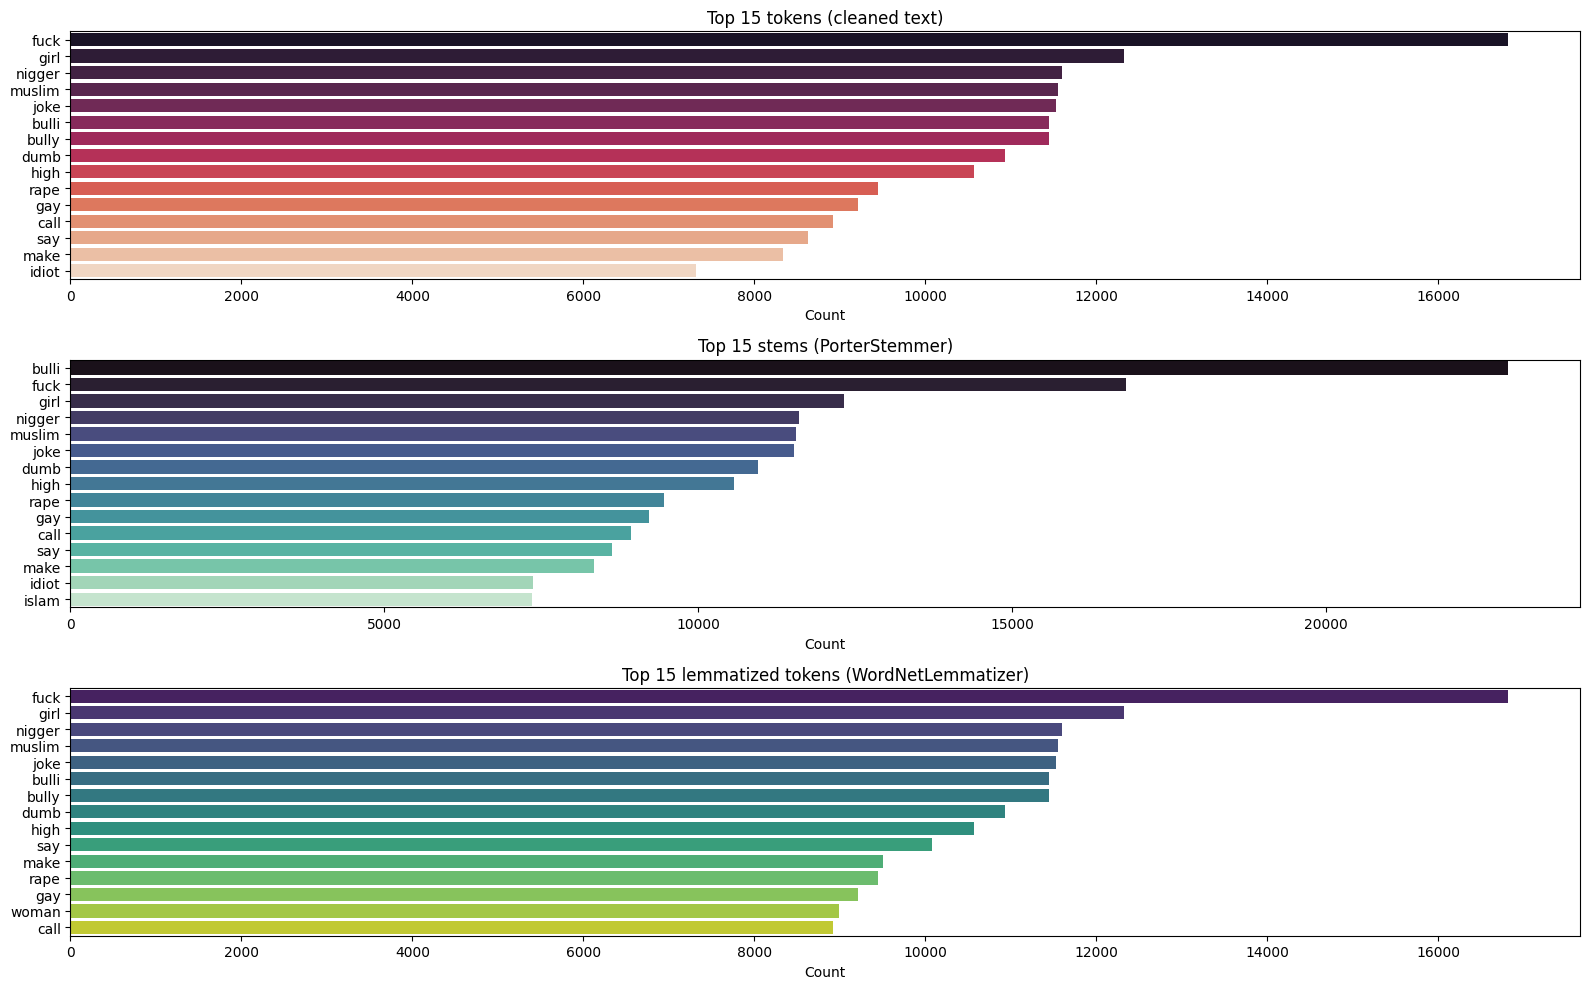

In [63]:
# Visualization


# helpers
ps = PorterStemmer()
wnl = WordNetLemmatizer()

def safe_tokenize(text):
    # use nltk.word_tokenize for better splitting; fallback to simple split
    try:
        toks = nltk.word_tokenize(str(text))
    except Exception:
        toks = str(text).split()
    # remove stray punctuation tokens
    toks = [t for t in toks if any(c.isalnum() for c in t)]
    return toks

def stem_tokens(tokens):
    return [ps.stem(t) for t in tokens]

def lemmatize_tokens(tokens):
    # simple verb-first then noun lemmatization to reduce inflections
    lems = []
    for t in tokens:
        v = wnl.lemmatize(t, pos='v')
        n = wnl.lemmatize(v, pos='n')
        lems.append(n)
    return lems

# pick sample rows to display
sample_n = 10
if len(df) <= sample_n:
    sample_idx = df.index.tolist()
else:
    # deterministic sample for reproducibility
    np.random.seed(42)
    sample_idx = np.random.choice(df.index, size=sample_n, replace=False)

rows = []
for ix in sample_idx:
    orig = df.at[ix, 'text'] if 'text' in df.columns else ""
    cleaned = df.at[ix, 'clean_text'] if 'clean_text' in df.columns else ""
    toks = safe_tokenize(cleaned)
    stems = stem_tokens(toks)
    lems = lemmatize_tokens(toks)
    rows.append({
        'index': ix,
        'original': orig,
        'cleaned': cleaned,
        'tokenized': " ".join(toks),
        'stemmed': " ".join(stems),
        'lemmatized': " ".join(lems)
    })

compare_df = pd.DataFrame(rows)[['index','original','cleaned','tokenized','stemmed','lemmatized']]
pd.set_option('display.max_colwidth', 200)
display(compare_df)

# --- Corpus-level top token comparison (before vs stemmed vs lemmatized) ---
# build counters from entire cleaned column 
if 'clean_text' not in df.columns:
    raise RuntimeError("df['clean_text'] not found. Run the cleaning cell first.")

corpus_clean = df['clean_text'].astype(str).tolist()

# gather token lists
all_tokens = []
all_stems = []
all_lems = []
for txt in corpus_clean:
    toks = safe_tokenize(txt)
    all_tokens.extend(toks)
    all_stems.extend(stem_tokens(toks))
    all_lems.extend(lemmatize_tokens(toks))

top_k = 15
top_tokens = Counter(all_tokens).most_common(top_k)
top_stems  = Counter(all_stems).most_common(top_k)
top_lems   = Counter(all_lems).most_common(top_k)

# prepare plotting
def unzip(counter_list):
    words, counts = zip(*counter_list) if counter_list else ([],[])
    return list(words), list(counts)

toks_w, toks_c = unzip(top_tokens)
stems_w, stems_c = unzip(top_stems)
lems_w, lems_c = unzip(top_lems)

plt.figure(figsize=(16,10))
plt.subplot(3,1,1)
sns.barplot(x=toks_c, y=toks_w, palette="rocket")
plt.title(f"Top {top_k} tokens (cleaned text)")
plt.xlabel("Count")

plt.subplot(3,1,2)
sns.barplot(x=stems_c, y=stems_w, palette="mako")
plt.title(f"Top {top_k} stems (PorterStemmer)")
plt.xlabel("Count")

plt.subplot(3,1,3)
sns.barplot(x=lems_c, y=lems_w, palette="viridis")
plt.title(f"Top {top_k} lemmatized tokens (WordNetLemmatizer)")
plt.xlabel("Count")

plt.tight_layout()
plt.show()


Training samples: 50993
Testing samples: 12749


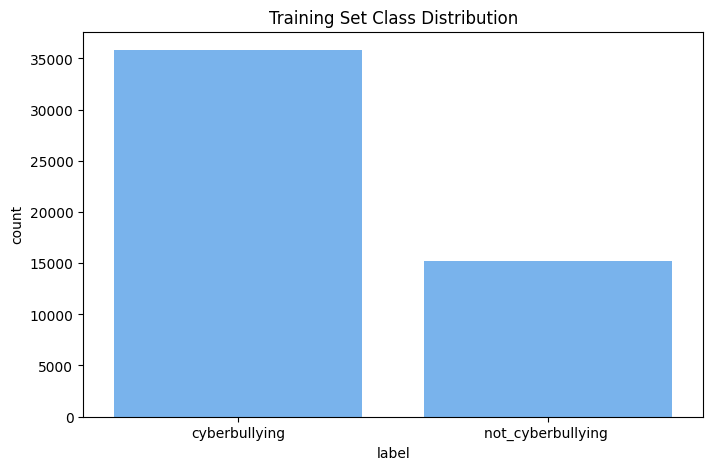

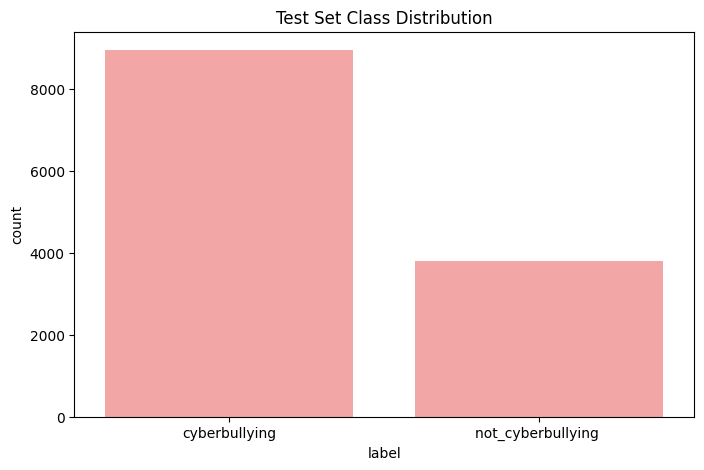

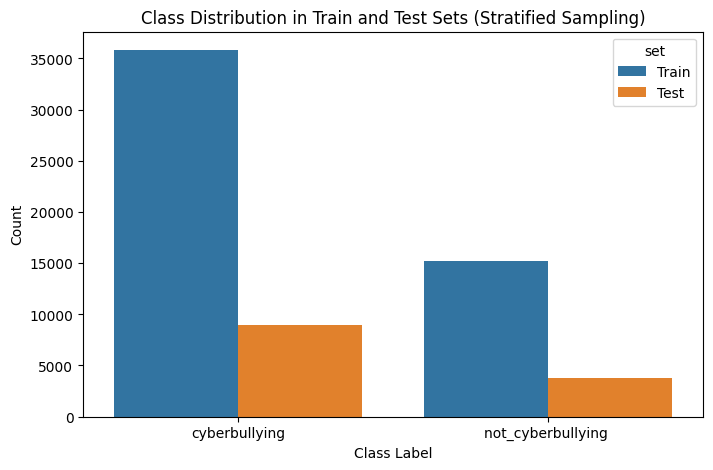

In [64]:
# Train/Test split with stratified sampling
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Optional visualization of class distribution
plt.figure(figsize=(8,5))
sns.countplot(x=y_train, color="#66b3ff")
plt.title("Training Set Class Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x=y_test, color="#ff9999")
plt.title("Test Set Class Distribution")
plt.show()

# Stratified sampling visualization (Train vs Test combined)
train_dist = pd.DataFrame({'label': y_train, 'set': 'Train'})
test_dist = pd.DataFrame({'label': y_test, 'set': 'Test'})
dist_df = pd.concat([train_dist, test_dist])

plt.figure(figsize=(8,5))
sns.countplot(data=dist_df, x='label', hue='set')
plt.title("Class Distribution in Train and Test Sets (Stratified Sampling)")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()

In [65]:
# Initialize TF-IDF
tfidf = TfidfVectorizer(
    max_features=50000,   # adjust if memory tight: 5000 / 10000
    ngram_range=(1,3),
    min_df=3,
    sublinear_tf=True,
    use_idf=True,
    lowercase=True,
    token_pattern=r"(?u)\b\w+\b"
)

# Fit only on training text
X_train_tfidf = tfidf.fit_transform(X_train)   # sparse CSR matrix
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF shapes (train/test):", X_train_tfidf.shape, X_test_tfidf.shape)

TF-IDF shapes (train/test): (50993, 50000) (12749, 50000)


In [66]:
# top-25 display
def get_feature_names_safe(vect):
    try:
        return vect.get_feature_names_out()
    except:
        return vect.get_feature_names()

def top_n_global(tfidf_matrix, vectorizer, n=25):
    sums = tfidf_matrix.sum(axis=0)
    arr = np.asarray(sums).ravel()
    fnames = get_feature_names_safe(vectorizer)
    top_idx = np.argsort(arr)[::-1][:n]
    return list(zip(fnames[top_idx], arr[top_idx]))

top25_global = top_n_global(X_train_tfidf, tfidf, n=25)
print("Top 25 TF-IDF tokens (global, training set):")
for i,(tok,sc) in enumerate(top25_global,1):
    print(f"{i:2d}. {tok:30s}  (score: {sc:.4f})")


Top 25 TF-IDF tokens (global, training set):
 1. fuck                            (score: 842.1420)
 2. nigger                          (score: 645.7090)
 3. bulli                           (score: 642.2085)
 4. bulli bully                     (score: 641.9261)
 5. bully                           (score: 641.9261)
 6. dumb                            (score: 635.0461)
 7. girl                            (score: 580.3647)
 8. high                            (score: 540.6715)
 9. fuck fuck                       (score: 517.6342)
10. muslim                          (score: 488.9783)
11. joke                            (score: 475.4675)
12. rape                            (score: 446.1908)
13. gay                             (score: 436.1517)
14. call                            (score: 431.7677)
15. say                             (score: 421.8620)
16. make                            (score: 420.0386)
17. nigger nigger                   (score: 387.4759)
18. dumb dumb                       (

In [67]:
#TextBlob Features

class TextBlobFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        polys = []
        subs = []
        for t in X:
            tb = TextBlob(str(t))
            polys.append(tb.sentiment.polarity)
            subs.append(tb.sentiment.subjectivity)
        arr = np.vstack([polys, subs]).T.astype(np.float32)  # shape (n_samples,2)
        return sparse.csr_matrix(arr)   # IMPORTANT: return sparse matrix

# Example: test transformer on training set
tb_feat = TextBlobFeatures().transform(X_train.values)
print("TextBlob features shape (sparse):", tb_feat.shape)



TextBlob features shape (sparse): (50993, 2)


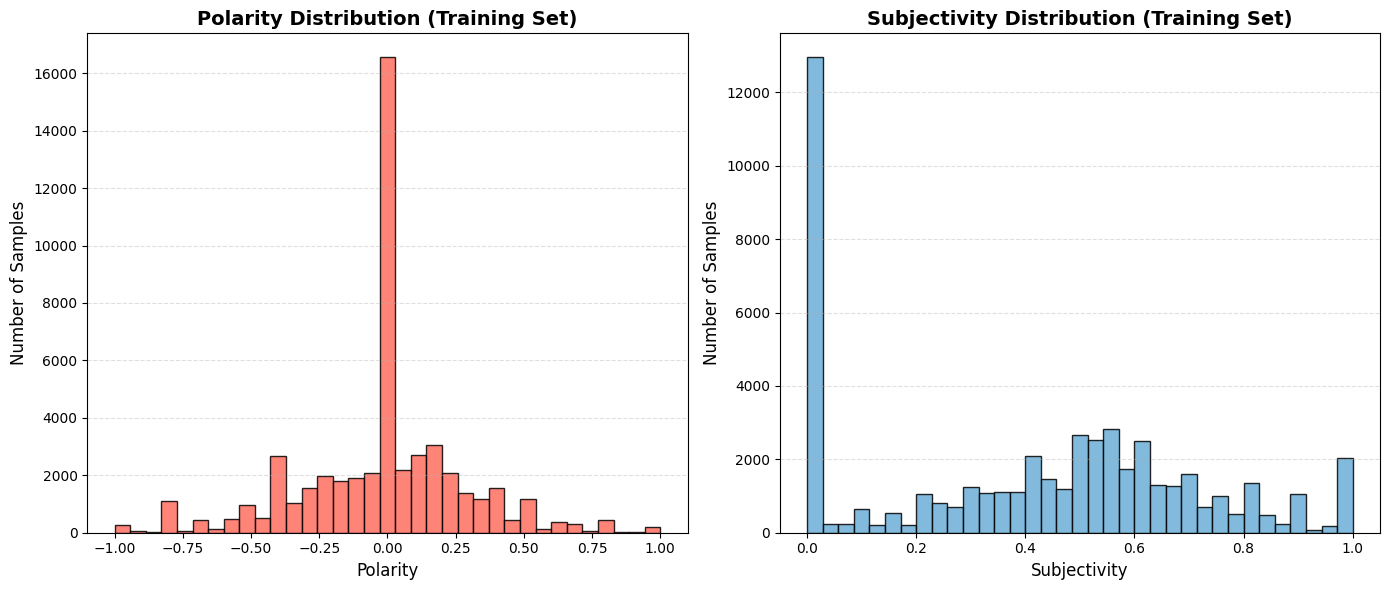

In [68]:
#Visualize TextBlob Features
def compute_textblob_array(X_raw):
    polys, subs = [], []
    for t in X_raw:
        try:
            tb = TextBlob(str(t))
            polys.append(tb.sentiment.polarity)
            subs.append(tb.sentiment.subjectivity)
        except Exception:
            polys.append(0.0)
            subs.append(0.0)
    return np.vstack([polys, subs]).T.astype(np.float32)

# Ensure tb_train exists — if not, compute it now
if 'tb_train' not in globals():
    tb_train = compute_textblob_array(X_train)

tb_train = np.asarray(tb_train)

# Styled visualization
plt.figure(figsize=(14,6))

# Polarity Plot
plt.subplot(1,2,1)
plt.hist(tb_train[:,0], bins=35, color='#FF6F61', edgecolor='black', alpha=0.85)
plt.title("Polarity Distribution (Training Set)", fontsize=14, fontweight='bold')
plt.xlabel("Polarity", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Subjectivity Plot
plt.subplot(1,2,2)
plt.hist(tb_train[:,1], bins=35, color='#6BAED6', edgecolor='black', alpha=0.85)
plt.title("Subjectivity Distribution (Training Set)", fontsize=14, fontweight='bold')
plt.xlabel("Subjectivity", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


In [15]:
# Convert sparse TF-IDF to dense and combine with TextBlob features

combined_features = FeatureUnion([
    ('tfidf', tfidf),                   # tfidf is a vectorizer; FeatureUnion will call .transform on raw text only if used in pipeline.
    ('textblob', TextBlobFeatures())
])

# If you want to get the combined features explicitly for diagnostics:
# Note: FeatureUnion expects raw X if components are transformers that accept raw X
# We'll compute combined features from X_train (raw texts)
combined_train = sparse.hstack([
    X_train_tfidf,                       # precomputed sparse TF-IDF for X_train
    TextBlobFeatures().transform(X_train.values)   # sparse (n_samples,2)
], format='csr')

combined_test = sparse.hstack([
    X_test_tfidf,
    TextBlobFeatures().transform(X_test.values)
], format='csr')

print("Combined train shape:", combined_train.shape)
print("Combined test  shape:", combined_test.shape)



Combined train shape: (50993, 20002)
Combined test  shape: (12749, 20002)


In [16]:
#  LABEL ENCODING 

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Label encoding mapping:")
for i, lab in enumerate(le.classes_):
    print(f"{i} -> {lab}")


Label encoding mapping:
0 -> cyberbullying
1 -> not_cyberbullying 


In [17]:
# TextBlob features (missing tb_train_scaled handler) 

def compute_textblob_array(X_raw):
    polys, subs = [], []
    for t in X_raw:
        try:
            tb = TextBlob(str(t))
            polys.append(tb.sentiment.polarity)
            subs.append(tb.sentiment.subjectivity)
        except Exception:
            polys.append(0.0)
            subs.append(0.0)
    return np.vstack([polys, subs]).T.astype(np.float32)

# Ensure X_train / X_test exist
if 'X_train' not in globals() or 'X_test' not in globals():
    raise RuntimeError("X_train / X_test not found. Run your train/test-split cell first.")

# Compute tb_train / tb_test if missing
if 'tb_train' not in globals():
    print("Computing tb_train...")
    tb_train = compute_textblob_array(X_train.values if hasattr(X_train, 'values') else X_train)
else:
    print("tb_train already exists.")

if 'tb_test' not in globals():
    print("Computing tb_test...")
    tb_test = compute_textblob_array(X_test.values if hasattr(X_test, 'values') else X_test)
else:
    print("tb_test already exists.")

# Fit or reuse tb_scaler and produce scaled arrays
if 'tb_scaler' not in globals():
    tb_scaler = StandardScaler()
    tb_train_scaled = tb_scaler.fit_transform(tb_train)
    tb_test_scaled  = tb_scaler.transform(tb_test)
    print("Fitted tb_scaler and produced tb_train_scaled / tb_test_scaled.")
else:
    # If scaler exists but scaled arrays missing, produce them; otherwise reuse existing
    if 'tb_train_scaled' not in globals():
        tb_train_scaled = tb_scaler.transform(tb_train) # type: ignore
    if 'tb_test_scaled' not in globals():
        tb_test_scaled = tb_scaler.transform(tb_test) # type: ignore
    print("Reused existing tb_scaler and ensured tb_train_scaled / tb_test_scaled exist.")

print("tb_train shape:", tb_train.shape, "tb_train_scaled shape:", tb_train_scaled.shape)


tb_train already exists.
Computing tb_test...
Fitted tb_scaler and produced tb_train_scaled / tb_test_scaled.
tb_train shape: (50993, 2) tb_train_scaled shape: (50993, 2)


In [18]:
# DIAGNOSTIC CELL 

check_vars = [
    'X_train', 'X_test',
    'X_train_tfidf', 'X_test_tfidf',
    'svd', 'X_train_svd', 'X_test_svd', 'X_train_svd_scaled', 'X_test_svd_scaled',
    'tb_train', 'tb_test', 'tb_train_scaled', 'tb_test_scaled',
    'X_train_combined', 'X_test_combined',
    'y_train', 'y_test', 'le', 'y_train_enc', 'y_test_enc'
]

print("=== Variable presence and quick shapes ===")
for v in check_vars:
    if v in globals():
        val = globals()[v]
        t = type(val).__name__
        shape = getattr(val, "shape", None)
        if shape is None:
            try:
                shape = (len(val),)
            except Exception:
                shape = None
        print(f"[OK] {v:20s} type={t:18s} shape={shape}")
    else:
        print(f"[MISSING] {v}")

# Quick content checks
errs = []
# TF-IDF sparse checks
if 'X_train_tfidf' in globals():
    if not sparse.issparse(X_train_tfidf):
        errs.append("X_train_tfidf is not sparse.")
    else:
        print("X_train_tfidf is sparse with shape", X_train_tfidf.shape)

# SVD -> row count vs TF-IDF
if 'X_train_svd' in globals() and 'X_train_tfidf' in globals():
    if X_train_svd.shape[0] != X_train_tfidf.shape[0]:
        errs.append(f"Row mismatch: X_train_svd rows {X_train_svd.shape[0]} != X_train_tfidf rows {X_train_tfidf.shape[0]}")

# tb_train shape vs X_train
if 'tb_train' in globals() and 'X_train_tfidf' in globals():
    if tb_train.shape[0] != X_train_tfidf.shape[0]:
        errs.append(f"Row mismatch: tb_train rows {tb_train.shape[0]} != X_train_tfidf rows {X_train_tfidf.shape[0]}")

# Combined presence consistency
if 'X_train_combined' in globals():
    if 'y_train_enc' in globals():
        if X_train_combined.shape[0] != len(y_train_enc):
            errs.append(f"Row mismatch: X_train_combined rows {X_train_combined.shape[0]} != y_train_enc length {len(y_train_enc)}")

# NaN/Inf checks for combined arrays (if present)
for name in ('X_train_combined','X_train_svd_scaled','tb_train_scaled'):
    if name in globals():
        arr = globals()[name]
        try:
            arrn = np.asarray(arr)
            if np.isnan(arrn).any() or np.isinf(arrn).any():
                errs.append(f"{name} contains NaN or Inf.")
        except Exception:
            pass

# label uniqueness and types
if 'y_train' in globals():
    print("y_train unique labels:", np.unique(y_train)[:10], "count:", len(np.unique(y_train)))
if 'y_train_enc' in globals():
    print("y_train_enc dtype:", getattr(y_train_enc,'dtype',None), "unique counts:", np.unique(y_train_enc, return_counts=True))

print("\n=== Diagnostic summary ===")
if errs:
    for e in errs:
        print("ERROR:", e)
else:
    print("No obvious shape/type/NaN issues detected. SMOTE failure may be due to missing X_train_combined variable specifically.")

# If X_train_combined missing, show recommended next cells to run
if 'X_train_combined' not in globals():
    print("\nAction: X_train_combined is missing. Run or re-run the cell that builds SVD + scales + concatenation.")
    print("Suggested reinstall order (run each cell in order):")
    print(" 1) TF-IDF fit on X_train -> X_train_tfidf, X_test_tfidf")
    print(" 2) TruncatedSVD fit on X_train_tfidf -> X_train_svd, X_test_svd")
    print(" 3) SVD scaler fit_transform -> X_train_svd_scaled, X_test_svd_scaled")
    print(" 4) TextBlob compute -> tb_train, tb_test")
    print(" 5) TextBlob scaler -> tb_train_scaled, tb_test_scaled")
    print(" 6) Combine -> X_train_combined = np.hstack([X_train_svd_scaled, tb_train_scaled])")


=== Variable presence and quick shapes ===
[OK] X_train              type=Series             shape=(50993,)
[OK] X_test               type=Series             shape=(12749,)
[OK] X_train_tfidf        type=csr_matrix         shape=(50993, 20000)
[OK] X_test_tfidf         type=csr_matrix         shape=(12749, 20000)
[MISSING] svd
[MISSING] X_train_svd
[MISSING] X_test_svd
[MISSING] X_train_svd_scaled
[MISSING] X_test_svd_scaled
[OK] tb_train             type=ndarray            shape=(50993, 2)
[OK] tb_test              type=ndarray            shape=(12749, 2)
[OK] tb_train_scaled      type=ndarray            shape=(50993, 2)
[OK] tb_test_scaled       type=ndarray            shape=(12749, 2)
[MISSING] X_train_combined
[MISSING] X_test_combined
[OK] y_train              type=Series             shape=(50993,)
[OK] y_test               type=Series             shape=(12749,)
[OK] le                   type=LabelEncoder       shape=None
[OK] y_train_enc          type=ndarray            shape=(50

In [19]:
#TruncatedSVD
import joblib

# PARAMETERS
svd_components = globals().get('svd_components', 150)
svd_random_state = globals().get('svd_random_state', 42)

# Preconditions
if 'X_train_tfidf' not in globals() or 'X_test_tfidf' not in globals():
    raise RuntimeError("Missing X_train_tfidf / X_test_tfidf. Run TF-IDF cell first.")

if 'X_train' not in globals() or 'X_test' not in globals():
    raise RuntimeError("Missing X_train / X_test (raw text). Run your train/test split cell first.")

# Fit or reuse TruncatedSVD (fit on train only)
if 'svd' not in globals():
    print("svd object not found — fitting TruncatedSVD on X_train_tfidf...")
    svd = TruncatedSVD(n_components=svd_components, random_state=svd_random_state)
    X_train_svd = svd.fit_transform(X_train_tfidf)
    X_test_svd  = svd.transform(X_test_tfidf)
    joblib.dump(svd, "svd_truncated.joblib")
    print("Fitted svd and saved svd_truncated.joblib")
else:
    # svd exists -> compute transforms if missing
    if 'X_train_svd' not in globals() or 'X_test_svd' not in globals():
        print("svd found; computing X_train_svd / X_test_svd via transform()...")
        X_train_svd = svd.transform(X_train_tfidf)
        X_test_svd  = svd.transform(X_test_tfidf)
    else:
        print("svd and SVD transforms already present.")

#  Fit or reuse SVD scaler (fit on X_train_svd only)
if 'svd_scaler' not in globals():
    print("svd_scaler not found — fitting StandardScaler on SVD components...")
    svd_scaler = StandardScaler()
    X_train_svd_scaled = svd_scaler.fit_transform(X_train_svd)
    X_test_svd_scaled  = svd_scaler.transform(X_test_svd)
    joblib.dump(svd_scaler, "svd_scaler.joblib")
    print("Fitted svd_scaler and saved svd_scaler.joblib")
else:
    if 'X_train_svd_scaled' not in globals() or 'X_test_svd_scaled' not in globals():
        X_train_svd_scaled = svd_scaler.transform(X_train_svd)
        X_test_svd_scaled  = svd_scaler.transform(X_test_svd)
    print("svd_scaler present and SVD-scaled arrays ready.")

# Ensure TextBlob numeric arrays exist, and scale them if needed
# compute tb_train/tb_test if missing (uses TextBlob transformer compute function if available)
if 'tb_train' not in globals() or 'tb_test' not in globals():
    # try to compute using compute_textblob_array if present
    if 'compute_textblob_array' in globals():
        print("Computing tb_train/tb_test using compute_textblob_array()...")
        tb_train = compute_textblob_array(X_train.values if hasattr(X_train,'values') else X_train)
        tb_test  = compute_textblob_array(X_test.values if hasattr(X_test,'values') else X_test)
    else:
        raise RuntimeError("tb_train/tb_test not found and compute_textblob_array() not available. Run the TextBlob feature cell first.")

# Fit or reuse tb_scaler (fit on tb_train only)
if 'tb_scaler' not in globals():
    print("tb_scaler not found — fitting StandardScaler on TextBlob features...")
    tb_scaler = StandardScaler()
    tb_train_scaled = tb_scaler.fit_transform(tb_train)
    tb_test_scaled  = tb_scaler.transform(tb_test)
    joblib.dump(tb_scaler, "tb_scaler.joblib")
    print("Fitted tb_scaler and saved tb_scaler.joblib")
else:
    if 'tb_train_scaled' not in globals() or 'tb_test_scaled' not in globals():
        tb_train_scaled = tb_scaler.transform(tb_train)
        tb_test_scaled  = tb_scaler.transform(tb_test)
    print("tb_scaler present and TextBlob-scaled arrays ready.")

# Final sanity checks: row alignment
n_svd = X_train_svd_scaled.shape[0]
n_tb  = tb_train_scaled.shape[0]
n_y   = len(y_train_enc) if 'y_train_enc' in globals() else len(y_train)

if n_svd != n_tb:
    raise RuntimeError(f"Row-mismatch: X_train_svd_scaled rows={n_svd} != tb_train_scaled rows={n_tb}. "
                       "This indicates your train split alignment is inconsistent. Ensure X_train, tb_train, and TF-IDF were created from the same indices.")
if n_svd != n_y:
    raise RuntimeError(f"Row-mismatch: X_train_svd_scaled rows={n_svd} != len(y_train_enc)={n_y}. "
                       "Ensure your labels align with training samples.")

# Build combined arrays
X_train_combined = np.hstack([X_train_svd_scaled, tb_train_scaled])
X_test_combined  = np.hstack([X_test_svd_scaled, tb_test_scaled])

print("Rebuilt combined matrices successfully:")
print(" X_train_combined shape:", X_train_combined.shape)
print(" X_test_combined  shape:", X_test_combined.shape)


svd object not found — fitting TruncatedSVD on X_train_tfidf...
Fitted svd and saved svd_truncated.joblib
svd_scaler not found — fitting StandardScaler on SVD components...
Fitted svd_scaler and saved svd_scaler.joblib
tb_scaler present and TextBlob-scaled arrays ready.
Rebuilt combined matrices successfully:
 X_train_combined shape: (50993, 152)
 X_test_combined  shape: (12749, 152)


In [20]:
#SMOTE

# Compute minority count and pick safe k_neighbors
minority_count = np.bincount(y_train_enc).min()
default_k = 5

if minority_count <= 1:
    raise RuntimeError(f"Too few minority samples for SMOTE (minority_count={minority_count}). "
                       "Cannot apply BorderlineSMOTE.")
# choose k as min(default_k, minority_count - 1)
k_neighbors_safe = min(default_k, max(1, minority_count - 1))
print(f"Using k_neighbors = {k_neighbors_safe} (minority_count={minority_count})")

# Apply BorderlineSMOTE (borderline-1)
sm = BorderlineSMOTE(kind="borderline-1",
                     k_neighbors=k_neighbors_safe,
                     random_state=smote_random_state if 'smote_random_state' in globals() else 42) # type: ignore

X_res, y_res = sm.fit_resample(X_train_combined, y_train_enc)

print("After Borderline-SMOTE class distribution:", dict(zip(*np.unique(y_res, return_counts=True))))
print("Resampled shape:", X_res.shape)


Using k_neighbors = 5 (minority_count=15162)
After Borderline-SMOTE class distribution: {np.int64(0): np.int64(35831), np.int64(1): np.int64(35831)}
Resampled shape: (71662, 152)


<Figure size 800x500 with 0 Axes>

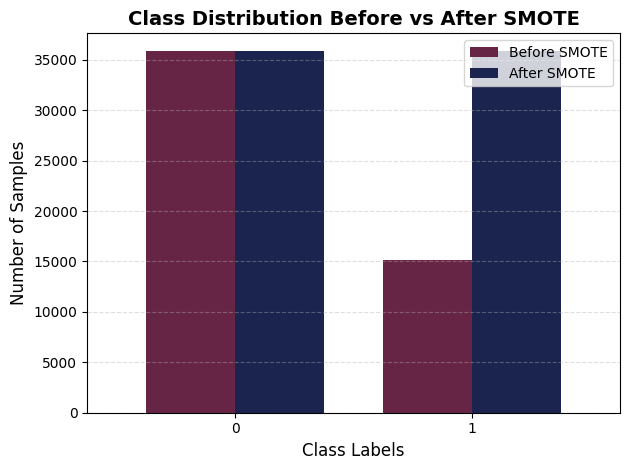

In [21]:
# VISUALIZATION: Before vs After SMOTE (clean + fixed)

before_counts = pd.Series(y_train_enc).value_counts().sort_index()
after_counts  = pd.Series(y_res).value_counts().sort_index()

df_compare = pd.DataFrame({
    "Before SMOTE": before_counts,
    "After SMOTE":  after_counts
}).astype(int)

plt.figure(figsize=(8,5))
df_compare.plot(kind='bar', color=["#672545", "#1A244E"], width=0.75)

plt.title("Class Distribution Before vs After SMOTE", fontsize=14, fontweight='bold')
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()



=== Training Random Forest ===


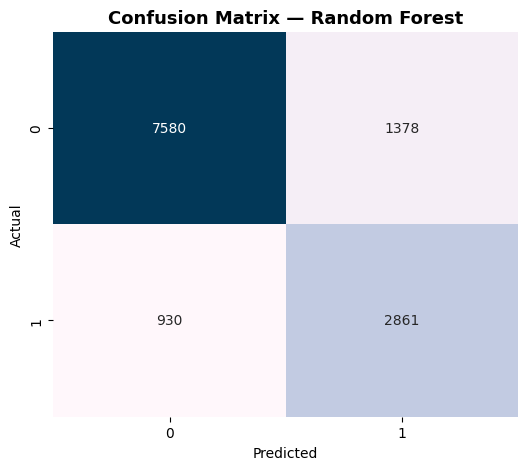


=== Training Logistic Regression ===


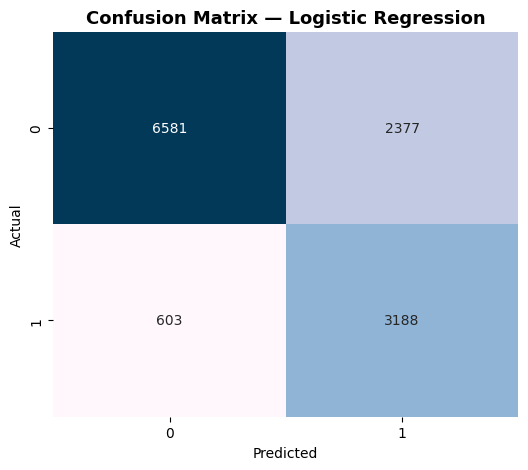


=== Training Support Vector Machine ===


c:\Users\adoc\Desktop\OCDssss\tf_env\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


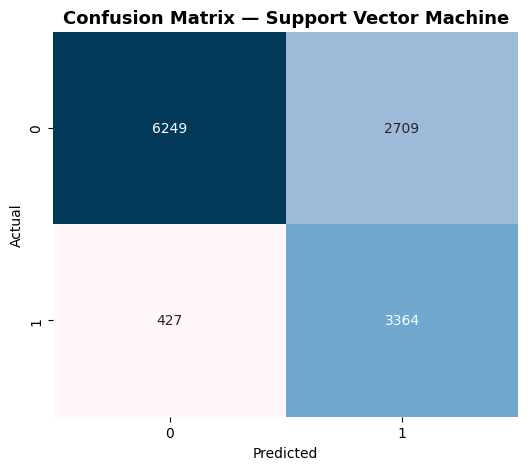


=== Training Decision Tree ===


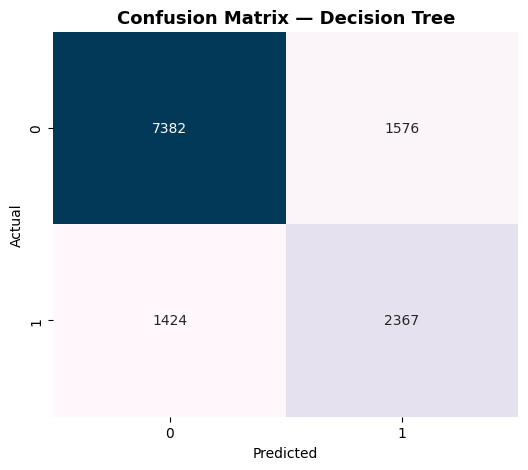

In [22]:
#TRAIN MULTIPLE ML MODELS

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=600,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        C=2.0,
        max_iter=3000,
        solver="saga",
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),
    "Support Vector Machine": LinearSVC(
        C=1.0,
        loss="hinge",
        max_iter=5000,
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n=== Training {name} ===")
    t0 = time.time()
    model.fit(X_res, y_res)                       
    train_time = time.time() - t0

    # predict on untouched test set
    y_pred = model.predict(X_test_combined) # type: ignore

    # metrics
    acc  = accuracy_score(y_test_enc, y_pred)
    prec = precision_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test_enc, y_pred, average='weighted', zero_division=0)

    results[name] = [acc, prec, rec, f1, train_time]

    # confusion matrix
    plt.figure(figsize=(6,5))
    cm = confusion_matrix(y_test_enc, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='PuBu', cbar=False)
    plt.title(f"Confusion Matrix — {name}", fontsize=13, fontweight='bold')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Naive Bayes feature shapes  (50993, 20002) (12749, 20002)


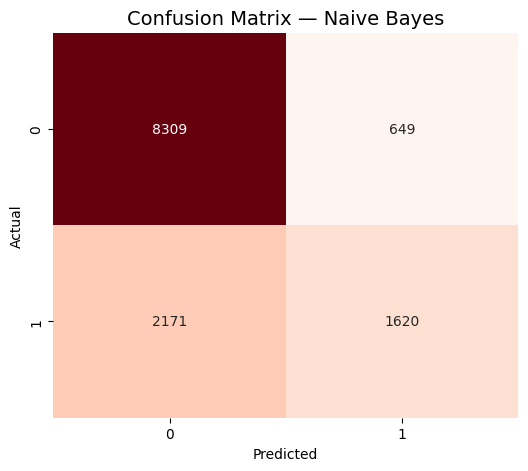

In [23]:
#Naive Bayes

#Compute TextBlob features for train/test
tb_train_nb = compute_textblob_array(X_train.values)   # shape (n_train, 2)
tb_test_nb  = compute_textblob_array(X_test.values)

#Shift polarity to non-negative range
# polarity ∈ [-1,1] → shift by +1 → [0,2]
tb_train_nb_shift = tb_train_nb.copy()
tb_test_nb_shift  = tb_test_nb.copy()

tb_train_nb_shift[:,0] += 1.0
tb_test_nb_shift[:,0]  += 1.0

# subjectivity is already 0–1, so no shift needed

#Scale TextBlob features to match TF-IDF magnitude
scaler_nb = MinMaxScaler()
tb_train_nb_scaled = scaler_nb.fit_transform(tb_train_nb_shift)
tb_test_nb_scaled  = scaler_nb.transform(tb_test_nb_shift)

#Convert TF-IDF to CSR and horizontally stack with TextBlob

X_train_nb_combined = sparse.hstack([X_train_tfidf, sparse.csr_matrix(tb_train_nb_scaled)], format='csr')
X_test_nb_combined  = sparse.hstack([X_test_tfidf,  sparse.csr_matrix(tb_test_nb_scaled)],  format='csr')

print("Naive Bayes feature shapes ", 
      X_train_nb_combined.shape, X_test_nb_combined.shape)

#Train Naive Bayes
nb_comb = MultinomialNB()
nb_comb.fit(X_train_nb_combined, y_train_enc)

y_pred_nb_comb = nb_comb.predict(X_test_nb_combined)

#Evaluation
nb_acc  = accuracy_score(y_test_enc, y_pred_nb_comb)
nb_prec = precision_score(y_test_enc, y_pred_nb_comb, average='weighted', zero_division=0)
nb_rec  = recall_score(y_test_enc, y_pred_nb_comb, average='weighted', zero_division=0)
nb_f1   = f1_score(y_test_enc, y_pred_nb_comb, average='weighted', zero_division=0)

#print("\n=== Naive Bayes ")
#print(f"Accuracy:  {nb_acc:.4f}")
#print(f"Precision: {nb_prec:.4f}")
#print(f"Recall:    {nb_rec:.4f}")
#print(f"F1 Score:  {nb_f1:.4f}")

# Confusion Matrix
cm_nb_comb = confusion_matrix(y_test_enc, y_pred_nb_comb)
plt.figure(figsize=(6,5))
sns.heatmap(cm_nb_comb, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title("Confusion Matrix — Naive Bayes", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [24]:
#  COMPARISON TABLE 
results["Naive Bayes"] = [nb_acc, nb_prec, nb_rec, nb_f1, np.nan]  
# find maximum length among all result value lists
max_len = max(len(v) for v in results.values())

# build appropriate index names for rows
base_names = ["Accuracy", "Precision", "Recall", "F1-score", "Train_time_s"]
index_names = base_names[:max_len]

#pad each result list to max_len with np.nan
results_padded = {}
for k, vals in results.items():
    vals_list = list(vals)
    if len(vals_list) < max_len:
        vals_list = vals_list + [np.nan] * (max_len - len(vals_list))
    results_padded[k] = vals_list

# construct DataFrame and transpose
comparison_df = pd.DataFrame(results_padded, index=index_names).T

#round numeric columns
for col in comparison_df.columns:
    if comparison_df[col].dtype.kind in 'fiu':  # numeric-like
        comparison_df[col] = comparison_df[col].round(4)

display(comparison_df)


,Accuracy,Precision,Recall,F1-score,Train_time_s
Random Forest,0.8190,0.8265,0.8190,0.8217,130.0415
Logistic Regression,0.7663,0.8140,0.7663,0.7756,9.7345
Support Vector Machine,0.7540,0.8224,0.7540,0.7645,80.4179
Decision Tree,0.7647,0.7675,0.7647,0.7660,55.8941
Naive Bayes,0.7788,0.7694,0.7788,0.7597,NaN


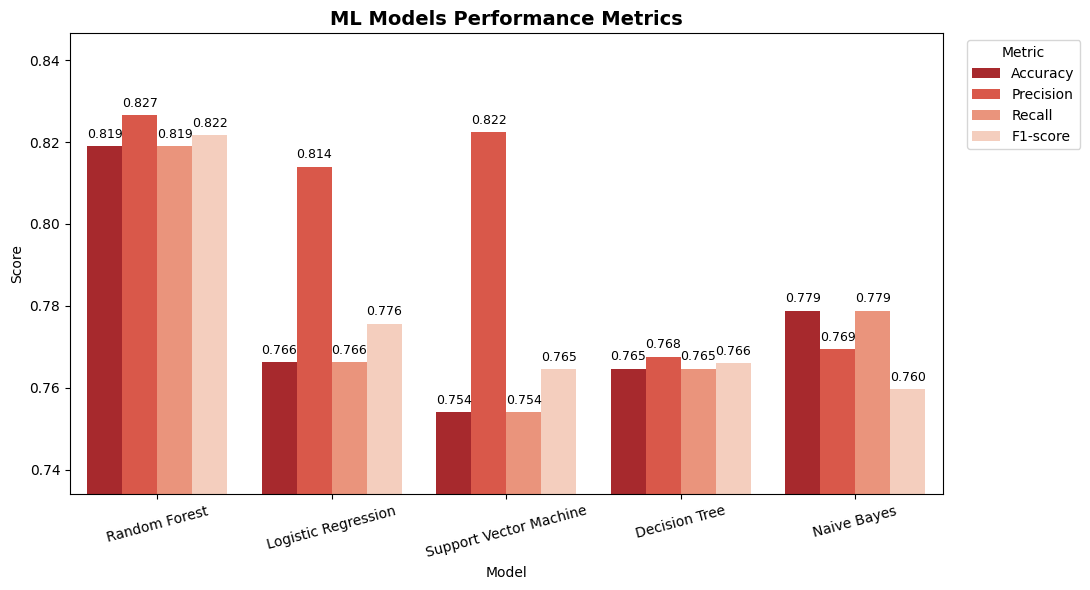

In [25]:
# MODEL PERFORMANCE BARPLOT 

#Pad results so all rows have equal length
max_len = max(len(v) for v in results.values())
base_names = ["Accuracy", "Precision", "Recall", "F1-score", "Train_time_s"]
index_names = base_names[:max_len]

results_padded = {}
for k, vals in results.items():
    vals_list = list(vals)
    if len(vals_list) < max_len:
        vals_list += [np.nan] * (max_len - len(vals_list))
    results_padded[k] = vals_list

# Build DataFrame
df = pd.DataFrame(results_padded, index=index_names).T.reset_index().rename(columns={'index': 'Model'})
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score"]
plot_df = df.melt(id_vars='Model', value_vars=metrics_to_plot, var_name='Metric', value_name='Score')
plot_df = plot_df.dropna(subset=['Score'])

# Colour
plt.figure(figsize=(11,6))
ax = sns.barplot(
    x='Model',
    y='Score',
    hue='Metric',
    data=plot_df,
    palette='Reds_r',
    #edgecolor='black'
)

# Adaptive y-limit
ymin = max(0, plot_df['Score'].min() - 0.02)
ymax = min(1, plot_df['Score'].max() + 0.02)
plt.ylim(ymin, ymax)

# Add score labels above bars
for p in ax.patches:
    height = p.get_height()
    if np.isfinite(height):
        ax.annotate(
            f"{height:.3f}",
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=9,
            xytext=(0, 4),
            textcoords='offset points'
        )

# Plot styling
plt.title("ML Models Performance Metrics", fontsize=14, fontweight='bold')
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


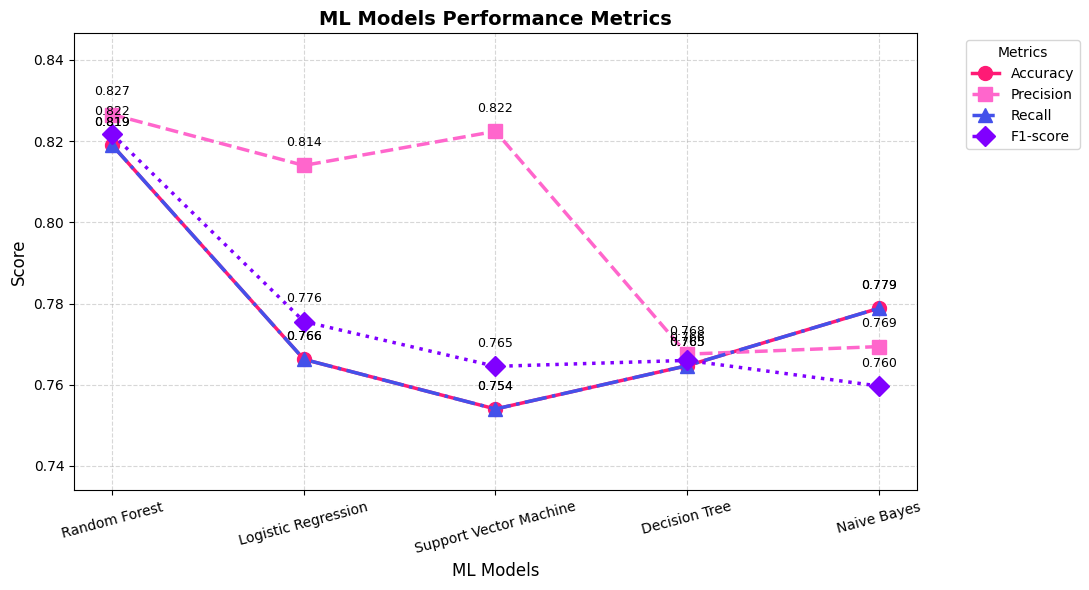

In [26]:
#LINE PLOT FOR MODEL PERFORMANCE

#  Convert results dict → padded DataFrame 
max_len = max(len(v) for v in results.values())
base_names = ["Accuracy", "Precision", "Recall", "F1-score", "Train_time_s"]
index_names = base_names[:max_len]

results_padded = {}
for k, vals in results.items():
    vals_list = list(vals)
    if len(vals_list) < max_len:
        vals_list += [np.nan] * (max_len - len(vals_list))
    results_padded[k] = vals_list

results_df = pd.DataFrame(results_padded, index=index_names).T.reset_index().rename(columns={'index':'Model'})

# Metrics you want to plot
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

# Styling
colors = ['#ff1a75','#ff66cc',"#4351ea",'#8000ff']
markers = ['o', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']

# X-axis (models)
x = np.arange(len(results_df['Model']))

# Dynamic Y-axis 
y_min = max(0, results_df[metrics].min().min() - 0.02)
y_max = min(1, results_df[metrics].max().max() + 0.02)

# PLOT
plt.figure(figsize=(11,6))

for metric, color, marker, ls in zip(metrics, colors, markers, linestyles):
    plt.plot(
        x,
        results_df[metric],
        marker=marker,
        linestyle=ls,
        linewidth=2.5,
        markersize=10,
        color=color,
        label=metric
    )
    
    # Label each point
    for xi, yi in zip(x, results_df[metric]):
        if not np.isnan(yi):
            plt.text(
                xi, yi + 0.004,
                f"{yi:.3f}",
                ha='center', va='bottom', fontsize=9
            )

# Formatting
plt.xticks(x, results_df['Model'], rotation=15)
plt.title("ML Models Performance Metrics", fontsize=14, fontweight='bold')
plt.xlabel("ML Models", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(y_min, y_max)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [28]:
from sklearn.decomposition import TruncatedSVD
#for name, obj in globals().items():
 #   if isinstance(obj, TruncatedSVD):
  #      print("SVD variable found:", name)


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

#for name, obj in globals().items():
 #   if isinstance(obj, TfidfVectorizer):
  #      print("TF-IDF vectorizer found:", name)


In [30]:
from sklearn.ensemble import RandomForestClassifier
#for name, obj in globals().items():
 #   if isinstance(obj, RandomForestClassifier):
  #      print("Random Forest model found:", name)


In [31]:
import joblib

# these names must exist in your notebook (you verified them)
#joblib.dump(rf_model, "rf_model.joblib")
#joblib.dump(tfidf, "tfidf_vectorizer.joblib")
#joblib.dump(svd, "svd.joblib")

#print("Saved artifacts: rf_model.joblib, tfidf_vectorizer.joblib, svd.joblib")


In [32]:
# EXTERNAL TESTING:RANDOM FOREST PREDICTIONS EVALUATION

external_file = "test-1.csv"    
text_col = "text"                


# ------------------ Load dataset ------------------
df_ext = pd.read_csv(external_file)
print("Loaded:", df_ext.shape)

# ------------------ Clean text ------------------
df_ext["clean_text"] = df_ext[text_col].astype(str).map(clean_text_improved)

# ------------------ TF-IDF (NO FIT) ------------------
X_ext_tfidf = tfidf.transform(df_ext["clean_text"])

# ------------------ TextBlob ------------------
tb_ext = compute_textblob_array(df_ext["clean_text"])
tb_ext_scaled = tb_scaler.transform(tb_ext)

# ------------------ SVD (NO FIT) ------------------
X_ext_svd = svd.transform(X_ext_tfidf)
X_ext_svd_scaled = svd_scaler.transform(X_ext_svd)

# ------------------ Combine ------------------
X_ext_combined = np.hstack([X_ext_svd_scaled, tb_ext_scaled])

# ------------------ Predict ------------------
rf_model = models["Random Forest"]  # your trained RF model
y_pred = rf_model.predict(X_ext_combined)

# decode 0/1 → text labels
df_ext["predicted_label"] = le.inverse_transform(y_pred)

# ------------------ Show output ------------------
display(df_ext[[text_col, "predicted_label"]].head(20))

# ------------------ Save output ------------------
df_ext.to_csv("test_predictions_only.csv", index=False)
print("Saved predictions → test_predictions_only.csv")


Loaded: (106, 2)


,text,predicted_label
0,Wishing you all the best in your exams.,not_cyberbullying
1,"Youâ€™re a joke, nobody cares about you.",cyberbullying
2,"Happy birthday, hope you have a wonderful day!",not_cyberbullying
3,"Just disappear, nobody will miss you.",not_cyberbullying
4,Wishing you all the best in your exams.,not_cyberbullying
5,"Youâ€™re such a loser, nobody likes you.",not_cyberbullying
6,"Great job on your project, well done!",not_cyberbullying
7,"You're annoying, everyone hates you.",not_cyberbullying
8,Thanks for helping me yesterday!,not_cyberbullying
9,"Youâ€™re a joke, nobody cares about you.",cyberbullying


Saved predictions → test_predictions_only.csv


In [33]:
# Download GloVe 100d embeddings (only once)
#import os
#import wget
#import zipfile

#glove_url = "http://nlp.stanford.edu/data/glove.6B.zip"
#zip_file = "glove.6B.zip"
#glove_file = "glove.6B.100d.txt"

# Download if not already present
#if not os.path.exists(zip_file):
 #   print("Downloading GloVe embeddings...")
  #  wget.download(glove_url)

# Extract only the 100d embeddings if not already extracted
#if not os.path.exists(glove_file):
 #   print("\nExtracting GloVe 100d embeddings...")
  #  with zipfile.ZipFile(zip_file, "r") as z:
   #     z.extract(glove_file)

#print("GloVe 100d embeddings ready!")


In [3]:
#Load GloVe into a dictionary

glove_path = "glove.6B.100d.txt"
embeddings_index = {}

with open(glove_path, 'r', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = vector

print("Loaded word vectors:", len(embeddings_index))


Loaded word vectors: 400000


In [4]:
#Tokenizer + Convert Text to Sequences
import tensorflow
from tensorflow.keras.preprocessing.text import Tokenizer # type: ignore
from tensorflow.keras.preprocessing.sequence import pad_sequences # type: ignore

# Convert to list (if needed)
X_train_list = X_train.tolist()
X_test_list = X_test.tolist()

# Tokenizer
tokenizer = Tokenizer(num_words=50000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_list)

# Convert text to integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_list)
X_test_seq = tokenizer.texts_to_sequences(X_test_list)

# Pad sequences (max length)
max_len = 120
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

vocab_size = len(tokenizer.word_index) + 1
vocab_size


NameError: name 'X_train' is not defined

In [ ]:
#Create Embedding Matrix for GloVe
embedding_dim = 100
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, idx in tokenizer.word_index.items():
    vector = embeddings_index.get(word)
    if vector is not None:
        embedding_matrix[idx] = vector

embedding_matrix.shape


(30864, 100)

In [ ]:
#Convert y_train / y_test to numpy
y_train_dl = np.array(y_train_enc)
y_test_dl = np.array(y_test_enc)


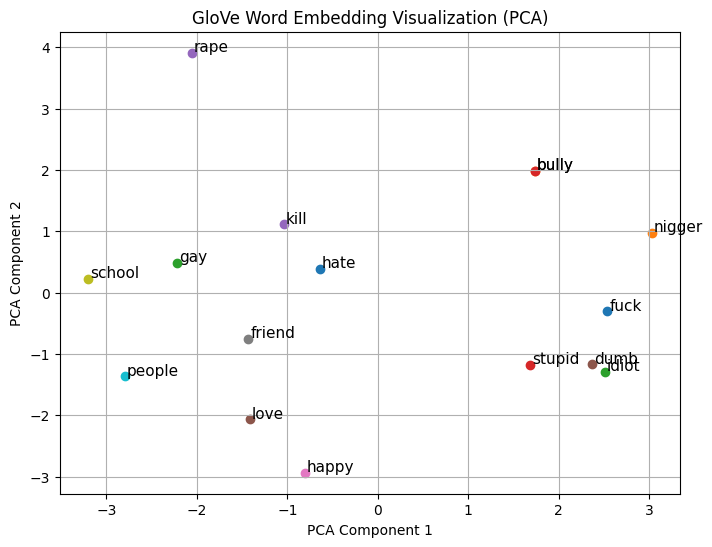

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Select words relevant to cyberbullying
words_to_plot = [
    "hate", "bully", "idiot", "stupid", "kill",
    "love", "happy", "friend", "school", "people", "fuck","nigger","gay","bully","rape","dumb"]

# Collect vectors
vectors = []
valid_words = []

for word in words_to_plot:
    if word in embeddings_index:
        vectors.append(embeddings_index[word])
        valid_words.append(word)

vectors = np.array(vectors)

# Reduce dimensions using PCA
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(8, 6))
for i, word in enumerate(valid_words):
    x, y = reduced_vectors[i]
    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, word, fontsize=11)

plt.title("GloVe Word Embedding Visualization (PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()


In [38]:
#LSTM Model
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional # type: ignore

lstm_model = Sequential([
    Input(shape=(max_len,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False
    ),
    
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.4),
    
    Dense(64, activation='relu'),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()


c:\Users\adoc\Desktop\OCDssss\tf_env\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 120, 100)       │     3,086,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,337,409 (12.73 MB)

 Trainable params: 251,009 (980.50 KB)

 Non-trainable params: 3,086,400 (11.77 MB)

In [39]:
#Train LSTM Model
# X_train_pad shape: (n_samples, max_len)
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train_pad, y_train_enc)   # duplicates minority rows

print("Before:", np.bincount(y_train_enc))
print("After :", np.bincount(y_res))

# Shuffle to avoid blocks of repeated minority samples
perm = np.random.permutation(len(y_res))
X_res = X_res[perm]
y_res = y_res[perm]

# Train on resampled sequences
history_lstm = lstm_model.fit(
    X_res, y_res,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    ],
    verbose=1
)


Before: [35831 15162]
After : [35831 35831]
Epoch 1/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 174s 187ms/step - accuracy: 0.8052 - loss: 0.4236 - val_accuracy: 0.8147 - val_loss: 0.4017 - learning_rate: 0.0010
Epoch 2/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 165s 184ms/step - accuracy: 0.8253 - loss: 0.3844 - val_accuracy: 0.8254 - val_loss: 0.3863 - learning_rate: 0.0010
Epoch 3/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 162s 181ms/step - accuracy: 0.8350 - loss: 0.3628 - val_accuracy: 0.8351 - val_loss: 0.3627 - learning_rate: 0.0010
Epoch 4/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 160s 178ms/step - accuracy: 0.8489 - loss: 0.3422 - val_accuracy: 0.8462 - val_loss: 0.3510 - learning_rate: 0.0010
Epoch 5/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 164s 183ms/step - accuracy: 0.8576 - loss: 0.3250 - val_accuracy: 0.8545 - val_loss: 0.3367 - learning_rate: 0.0010
Epoch 6/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 159s 177ms/step - accuracy: 0.8683 - loss: 0.3049 - val_accuracy: 0.8584 - val_loss: 0.3306 - learning_rate: 0.0010
Epoch 7/50
896/896 ━

399/399 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step
LSTM Performance:
Accuracy: 0.8147305671033023
Precision: 0.8508028222358686
Recall: 0.8147305671033023
F1: 0.8215611410519579


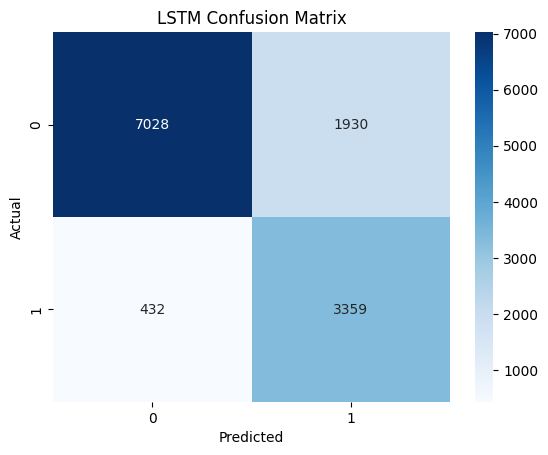

In [40]:
#Evaluate LSTM + Confusion Matrix

y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

acc_lstm = accuracy_score(y_test_dl, y_pred_lstm)
prec_lstm = precision_score(y_test_dl, y_pred_lstm, average='weighted')
rec_lstm = recall_score(y_test_dl, y_pred_lstm, average='weighted')
f1_lstm = f1_score(y_test_dl, y_pred_lstm, average='weighted')

print("LSTM Performance:")
print("Accuracy:", acc_lstm)
print("Precision:", prec_lstm)
print("Recall:", rec_lstm)
print("F1:", f1_lstm)

cm = confusion_matrix(y_test_dl, y_pred_lstm)
sns.heatmap(cm, annot=True, cmap="Blues", fmt='d')
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [42]:
# ================= Evaluation for LSTM =================

external_file = "test-2.csv"
text_col = "text"
label_col = "label"   


# --- Load ---
df_ext = pd.read_csv(external_file)
print("Loaded:", df_ext.shape)

# --- Clean text (uses your existing function) ---
df_ext["clean_text"] = df_ext[text_col].astype(str).map(clean_text_improved)

# --- Tokenize & pad (use your tokenizer and max_len) ---
ext_sequences = tokenizer.texts_to_sequences(df_ext["clean_text"])
X_ext_pad = pad_sequences(ext_sequences, maxlen=max_len)

# --- Predict probabilities and binary preds (use best_threshold if known) ---
y_ext_prob = lstm_model.predict(X_ext_pad, verbose=1).ravel()
best_threshold = globals().get("best_threshold", 0.5)   # use tuned threshold if available
y_ext_pred = (y_ext_prob > best_threshold).astype(int)

# --- Prepare predicted label names (if you have a LabelEncoder 'le') ---
if 'le' in globals():
    try:
        pred_label_names = le.inverse_transform(y_ext_pred)
    except Exception:
        # fallback: create simple mapping 0->"0", 1->"1"
        pred_label_names = y_ext_pred.astype(str)
else:
    # No label encoder in scope — use simple names
    pred_label_names = y_ext_pred.astype(str)

df_ext["predicted_label"] = pred_label_names

# --- If external true labels exist: convert them to integer classes safely ---
if label_col in df_ext.columns:
    raw_labels = df_ext[label_col].astype(str).values

    # Try converting to int first (if they are numeric strings)
    true_ints = None
    try:
        true_ints = df_ext[label_col].astype(int).values
        print("True labels are integer-like.")
    except Exception:
        # Not integer-like. Prefer using existing LabelEncoder 'le' if available.
        if 'le' in globals():
            # Handle unseen labels: map unseen to -1 and warn
            unseen_mask = ~np.isin(raw_labels, le.classes_)
            if unseen_mask.any():
                print("Warning: some external labels are unknown to the LabelEncoder and will be marked -1.")
            # For safe transform, temporarily extend classes if needed (scikit-learn <= doesn't allow transform on unseen)
            # So create a mapping dict from le
            le_map = {c: i for i, c in enumerate(le.classes_)}
            true_ints = np.array([le_map.get(v, -1) for v in raw_labels])
        else:
            # No LabelEncoder available — create mapping from external labels (factorize)
            unique_vals, encoded = np.unique(raw_labels, return_inverse=True)
            true_ints = encoded
            print("No LabelEncoder found. Mapped external labels to integers via factorize:", dict(enumerate(unique_vals)))

    # Now we have true_ints (may contain -1 for unknowns)
    df_ext["_true_int"] = true_ints

    # Exclude rows with -1 (unseen labels) from evaluation, but still save predictions
    eval_mask = df_ext["_true_int"] != -1
    if eval_mask.sum() == 0:
        print("No valid true labels available for evaluation after mapping. Predictions saved, evaluation skipped.")
    else:
        y_true_eval = df_ext.loc[eval_mask, "_true_int"].values
        y_pred_eval = y_ext_pred[eval_mask]

        acc = accuracy_score(y_true_eval, y_pred_eval)
        prec = precision_score(y_true_eval, y_pred_eval, average='weighted', zero_division=0)
        rec = recall_score(y_true_eval, y_pred_eval, average='weighted', zero_division=0)
        f1 = f1_score(y_true_eval, y_pred_eval, average='weighted', zero_division=0)

        print("\n=== LSTM External Evaluation ===")
        print(f"Samples evaluated: {eval_mask.sum()} / {len(df_ext)}")
        print(f"Accuracy : {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall   : {rec:.4f}")
        print(f"F1-score : {f1:.4f}")

        # Confusion Matrix (show only for valid-eval portion)
        cm = confusion_matrix(y_true_eval, y_pred_eval)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title("LSTM External Test - Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

# --- Show sample outputs and save ---
display(df_ext[[text_col, "clean_text", "predicted_label"]].head(20))

out_fname = "external_lstm_predictions.csv"
df_ext.to_csv(out_fname, index=False)
print("\nSaved →", out_fname)


Loaded: (108, 2)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
No valid true labels available for evaluation after mapping. Predictions saved, evaluation skipped.


,text,clean_text,predicted_label
0,"You're annoying, everyone hates you.",annoy everyone hat,not_cyberbullying
1,"Happy birthday, hope you have a wonderful day!",happy birthday hope wonderful day,not_cyberbullying
2,"Youâ€™re a joke, nobody cares about you.",joke nobody care,not_cyberbullying
3,"Nice work team, proud of you!",nice work team proud,not_cyberbullying
4,"Pathetic, you should just quit.",pathetic quit,not_cyberbullying
5,"Nice work team, proud of you!",nice work team proud,not_cyberbullying
6,"Youâ€™re a joke, nobody cares about you.",joke nobody care,not_cyberbullying
7,Wishing you all the best in your exams.,wish best exam,not_cyberbullying
8,You're nothing but a failure.,nothing failure,not_cyberbullying
9,"Happy birthday, hope you have a wonderful day!",happy birthday hope wonderful day,not_cyberbullying



Saved → external_lstm_predictions.csv


In [43]:
#CNN Model
from tensorflow.keras.models import Model # type: ignore
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Concatenate # type: ignore
from tensorflow.keras.layers import SpatialDropout1D, Dropout, Dense, BatchNormalization # type: ignore
from tensorflow.keras.optimizers import Adam # type: ignore

inp = Input(shape=(max_len,))

x = Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              input_length=max_len,
              trainable=False)(inp)

x = SpatialDropout1D(0.2)(x)

# parallel convs with different kernel sizes
convs = []
for k in (3, 4, 5):
    c = Conv1D(filters=128, kernel_size=k, activation='relu', padding='valid')(x)
    c = GlobalMaxPooling1D()(c)
    convs.append(c)

x = Concatenate()(convs)                 # shape: (None, 128*3)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(1, activation='sigmoid')(x)

cnn_model = Model(inputs=inp, outputs=out)
cnn_model.compile(loss='binary_crossentropy',
                  optimizer=Adam(learning_rate=1e-4),
                  metrics=['accuracy'])
cnn_model.summary()


c:\Users\adoc\Desktop\OCDssss\tf_env\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 120)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 120, 100)  │  3,086,400 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 120, 100)  │          0 │ embedding_1[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 118, 128)  │     38,528 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 117, 128)  │     51,328 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 116, 128)  │     64,128 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 384)       │      1,536 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 384)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     24,640 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,266,625 (12.46 MB)

 Trainable params: 179,457 (701.00 KB)

 Non-trainable params: 3,087,168 (11.78 MB)

In [44]:
#Train CNN Model
history_cnn = cnn_model.fit(
    X_train_pad, y_train_dl,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    verbose=1
)


Epoch 1/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.7243 - loss: 0.5654 - val_accuracy: 0.7728 - val_loss: 0.4124
Epoch 2/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.7532 - loss: 0.4831 - val_accuracy: 0.7732 - val_loss: 0.4065
Epoch 3/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.7613 - loss: 0.4585 - val_accuracy: 0.7793 - val_loss: 0.4009
Epoch 4/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.7687 - loss: 0.4402 - val_accuracy: 0.7793 - val_loss: 0.3944
Epoch 5/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.7765 - loss: 0.4266 - val_accuracy: 0.7840 - val_loss: 0.3894
Epoch 6/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.7788 - loss: 0.4158 - val_accuracy: 0.7864 - val_loss: 0.3850
Epoch 7/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.7829 - loss: 0.4077 - val_accuracy: 0.7920 - val_loss: 0.3820
Epoch 8/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.7886 - loss: 0.4013 - 

399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
CNN Performance:
Accuracy: 0.8141815044317201
Precision: 0.8288487814462381
Recall: 0.8141815044317201
F1: 0.8185346693763791


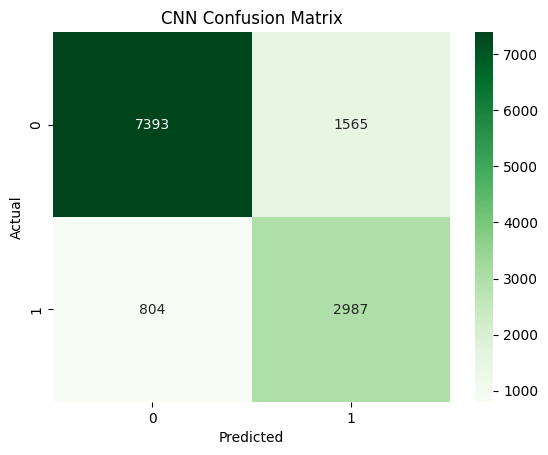

In [45]:
#Evaluate CNN + Confusion Matrix
y_pred_cnn = (cnn_model.predict(X_test_pad) > 0.5).astype(int).flatten()

acc_cnn = accuracy_score(y_test_dl, y_pred_cnn)
prec_cnn = precision_score(y_test_dl, y_pred_cnn, average='weighted')
rec_cnn = recall_score(y_test_dl, y_pred_cnn, average='weighted')
f1_cnn = f1_score(y_test_dl, y_pred_cnn, average='weighted')

print("CNN Performance:")
print("Accuracy:", acc_cnn)
print("Precision:", prec_cnn)
print("Recall:", rec_cnn)
print("F1:", f1_cnn)

cm = confusion_matrix(y_test_dl, y_pred_cnn)
sns.heatmap(cm, annot=True, cmap="Greens", fmt='d')
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


,Accuracy,Precision,Recall,F1-score
LSTM,0.8147,0.8508,0.8147,0.8216
CNN,0.8142,0.8288,0.8142,0.8185


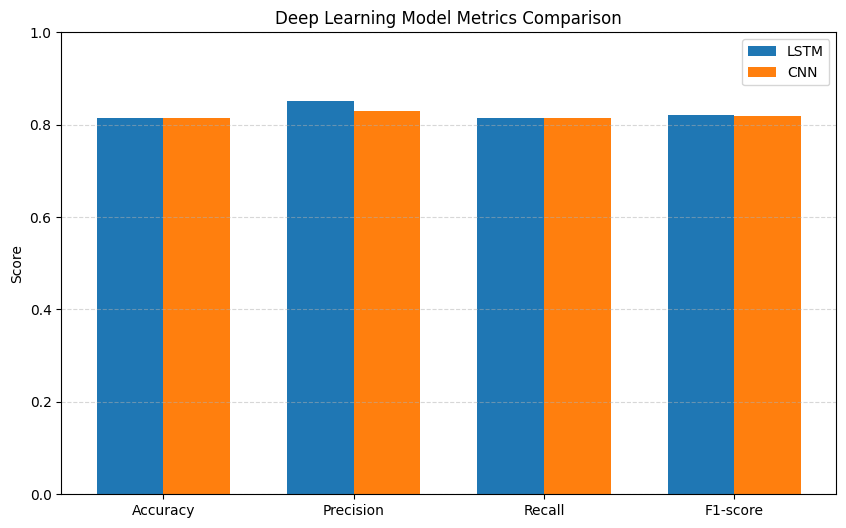

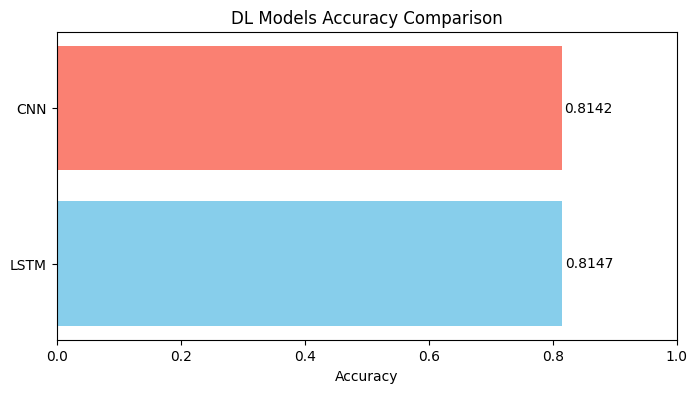

In [46]:
#Deep Learning Results

dl_results = {
    "LSTM": [acc_lstm, prec_lstm, rec_lstm, f1_lstm],
    "CNN":  [acc_cnn, prec_cnn, rec_cnn, f1_cnn]
}

# Create DataFrame
dl_df = pd.DataFrame(dl_results, index=["Accuracy", "Precision", "Recall", "F1-score"]).T
display(dl_df.style.background_gradient(cmap='Blues').format("{:.4f}"))


# Grouped Bar Plot (all metrics)
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = np.arange(len(metrics))
bar_width = 0.35

plt.figure(figsize=(10,6))
for i, model in enumerate(dl_df.index):
    plt.bar(x + i*bar_width, dl_df.loc[model], width=bar_width, label=model)

plt.xticks(x + bar_width/2, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Deep Learning Model Metrics Comparison")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Horizontal Bar Plot 

plt.figure(figsize=(8,4))
plt.barh(dl_df.index, dl_df["Accuracy"], color=['skyblue', 'salmon'])
for i, v in enumerate(dl_df["Accuracy"]):
    plt.text(v + 0.005, i, f"{v:.4f}", va='center')
plt.xlim(0, 1)
plt.xlabel("Accuracy")
plt.title("DL Models Accuracy Comparison")
plt.show()


,Accuracy,Precision,Recall,F1-score,Train_time_s
Random Forest,0.8190,0.8265,0.8190,0.8217,130.0415
Logistic Regression,0.7663,0.8140,0.7663,0.7756,9.7345
Support Vector Machine,0.7540,0.8224,0.7540,0.7645,80.4179
Decision Tree,0.7647,0.7675,0.7647,0.7660,55.8941
Naive Bayes,0.7788,0.7694,0.7788,0.7597,nan
LSTM,0.8147,0.8508,0.8147,0.8216,nan
CNN,0.8142,0.8288,0.8142,0.8185,nan


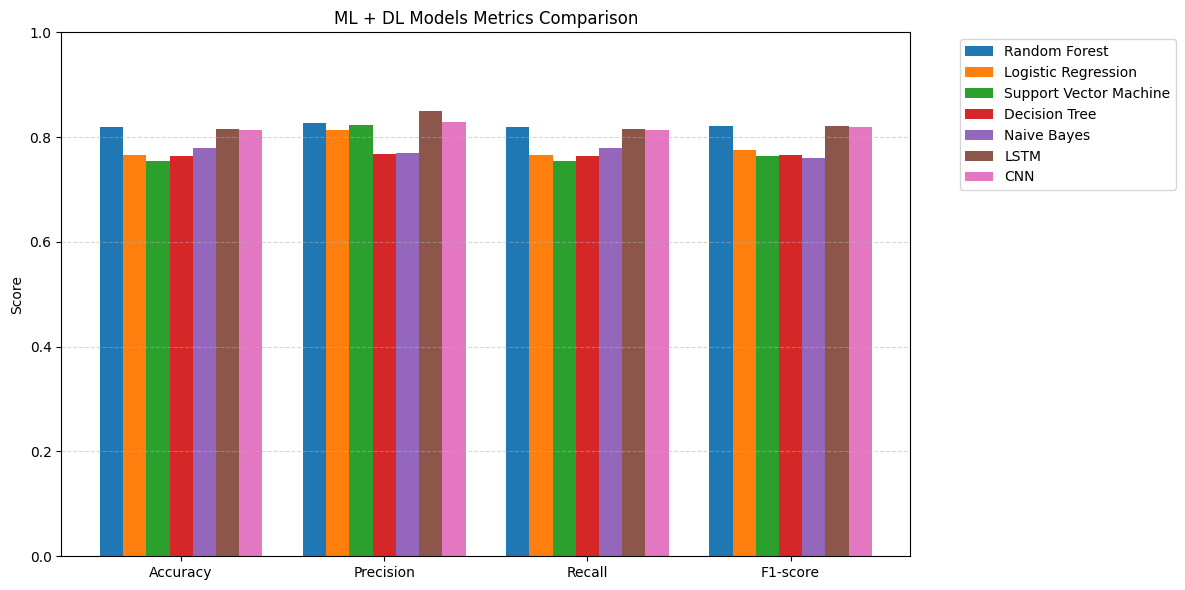

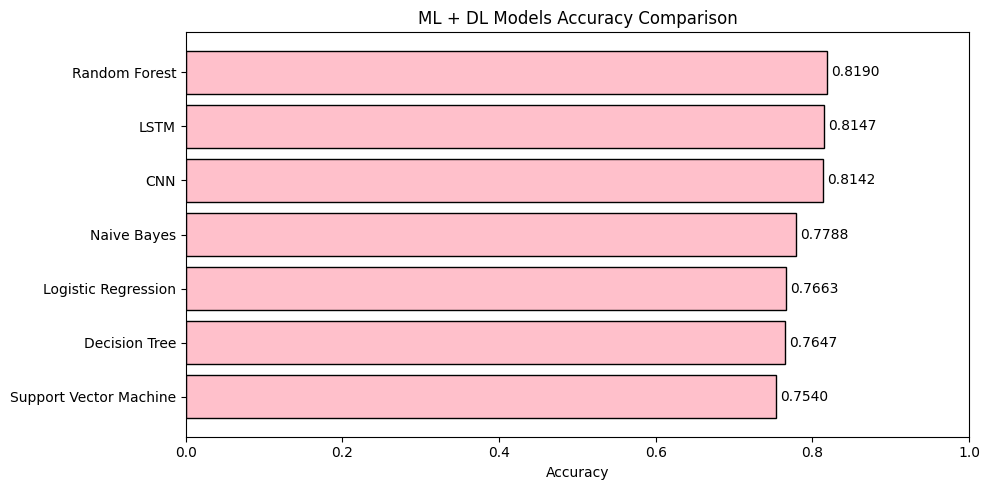

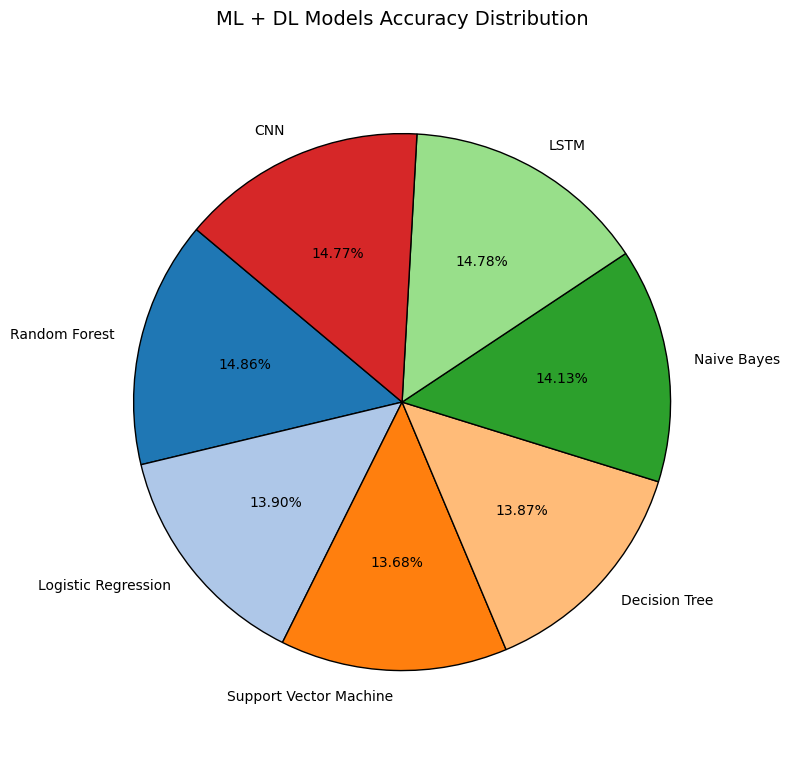

In [48]:
#ALL GRAPHS

all_results = {**results, **dl_results}

# Pad lists to uniform length
max_len = max(len(v) for v in all_results.values())
base_names = ["Accuracy", "Precision", "Recall", "F1-score", "Train_time_s"]
index_names = base_names[:max_len]

padded = {}
for k, vals in all_results.items():
    vals_list = list(vals)
    if len(vals_list) < max_len:
        vals_list += [np.nan] * (max_len - len(vals_list))
    padded[k] = vals_list

# Create DataFrame
all_df = pd.DataFrame(padded, index=index_names).T

# Round numeric columns for display
for col in all_df.columns:
    if pd.api.types.is_numeric_dtype(all_df[col]):
        all_df[col] = all_df[col].round(4)

# Display styled table
display(all_df.style.background_gradient(cmap='coolwarm').format("{:.4f}"))

# Ensure metrics present for plotting (use first 4 rows of index_names)
metrics = index_names[:4]

# Grouped Bar Plot - all models
plt.figure(figsize=(12,6))
x = np.arange(len(metrics))
bar_width = 0.8 / len(all_df.index)  # adaptive width
for i, model in enumerate(all_df.index):
    vals = all_df.loc[model, metrics].values.astype(float)
    plt.bar(x + i*bar_width, vals, width=bar_width, label=model)

plt.xticks(x + bar_width*(len(all_df.index)-1)/2, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("ML + DL Models Metrics Comparison")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Horizontal Bar Plot (Accuracy)
if "Accuracy" in all_df.columns:
    plt.figure(figsize=(10,5))
    sorted_df = all_df.sort_values("Accuracy", ascending=True)
    plt.barh(sorted_df.index, sorted_df["Accuracy"], color='pink', edgecolor='k')
    for i, v in enumerate(sorted_df["Accuracy"]):
        if not np.isnan(v):
            plt.text(v + 0.005, i, f"{v:.4f}", va='center')
    plt.xlim(0,1)
    plt.xlabel("Accuracy")
    plt.title("ML + DL Models Accuracy Comparison")
    plt.tight_layout()
    plt.show()

# Pie Chart - Accuracy distribution (skip NaNs)
if "Accuracy" in all_df.columns:
    acc_vals = all_df["Accuracy"].fillna(0)
    plt.figure(figsize=(8,8))
    colors = plt.cm.tab20.colors
    plt.pie(acc_vals, labels=all_df.index, autopct='%1.2f%%', startangle=140, colors=colors, wedgeprops={'edgecolor':'k'})
    plt.title("ML + DL Models Accuracy Distribution", fontsize=14)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
